# Week 6 Day 1 — PyTorch Basics + First Neural Network

## What I built:
- PyTorch tensors — creation, operations, shapes
- Autograd — automatic gradient calculation
- Manual gradient descent step — forward, backward, update
- TitanicNet — 3 hidden layers, Dropout, Sigmoid output
- Training loop from scratch — 100 epochs
- Learning curves — loss and accuracy plotted

## Architecture:
Input(8) → Linear(64) → ReLU → Dropout(0.3)
         → Linear(32) → ReLU → Dropout(0.3)
         → Linear(16) → ReLU
         → Linear(1)  → Sigmoid
Total parameters: 3,201

## Key concepts:
- model.train() → enables Dropout (training)
- model.eval()  → disables Dropout (evaluation)
- torch.no_grad() → no gradient tracking (validation)
- optimizer.zero_grad() → reset gradients each step
- loss.backward() → calculate all gradients via chain rule
- optimizer.step() → update all weights

## Results:
Logistic Regression : 0.8159 (5-fold CV)
Random Forest       : 0.8036 (5-fold CV)
Neural Network      : 0.8324 (single val split)

## Key learning:
Neural networks are competitive on Titanic but not clearly better.
For tabular data — gradient boosting (XGBoost/LightGBM) usually wins.
Neural networks shine on images, text, audio — not structured tables.

# PyTorch tensors:

In [1]:
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")

# ── Tensors — the basic building block ───────────────────────

# create tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"\nTensor a      : {a}")
print(f"Tensor b      : {b}")
print(f"Shape         : {a.shape}")
print(f"Dtype         : {a.dtype}")
print(f"a + b         : {a + b}")
print(f"a * b         : {a * b}")
print(f"dot product   : {torch.dot(a, b)}")

# 2D tensor (matrix)
W = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])
print(f"\nMatrix W shape: {W.shape}")
print(f"Matrix W:\n{W}")

# from numpy
arr = np.array([1.0, 2.0, 3.0])
t   = torch.from_numpy(arr)
print(f"\nFrom numpy: {t}")

# random tensors
r = torch.randn(3, 4)   # normal distribution
print(f"\nRandom (3,4):\n{r}")
print(f"Shape: {r.shape}")

PyTorch version: 2.13.0+cpu

Tensor a      : tensor([1., 2., 3.])
Tensor b      : tensor([4., 5., 6.])
Shape         : torch.Size([3])
Dtype         : torch.float32
a + b         : tensor([5., 7., 9.])
a * b         : tensor([ 4., 10., 18.])
dot product   : 32.0

Matrix W shape: torch.Size([3, 2])
Matrix W:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

From numpy: tensor([1., 2., 3.], dtype=torch.float64)

Random (3,4):
tensor([[ 0.7685,  0.7856,  0.7669,  0.4284],
        [-0.6731,  1.1058,  0.3863,  1.0698],
        [-0.1819,  0.6082, -1.2851, -0.8003]])
Shape: torch.Size([3, 4])


# Autograd (automatic gradient calculation):

In [2]:
# ── Autograd — PyTorch's magic ───────────────────────────────

# requires_grad=True tells PyTorch to track operations
x = torch.tensor(2.0, requires_grad=True)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

# forward pass — simple equation: y = w*x + b
y = w * x + b
print(f"x={x.item()}, w={w.item()}, b={b.item()}")
print(f"y = w*x + b = {y.item()}")

# loss — how wrong are we? (pretend target is 10)
target = torch.tensor(10.0)
loss   = (y - target) ** 2
print(f"\ntarget = {target.item()}")
print(f"loss   = (y - target)² = {loss.item()}")

# backward pass — calculate gradients
loss.backward()

print(f"\nGradients (how much each param affects loss):")
print(f"  d(loss)/d(w) = {w.grad.item():.4f}")
print(f"  d(loss)/d(x) = {x.grad.item():.4f}")
print(f"  d(loss)/d(b) = {b.grad.item():.4f}")

print(f"\nManual verification:")
print(f"  d(loss)/d(w) = 2*(y-target)*x = {2*(y.item()-target.item())*x.item():.4f}")
print(f"  d(loss)/d(b) = 2*(y-target)*1 = {2*(y.item()-target.item())*1:.4f}")

x=2.0, w=3.0, b=1.0
y = w*x + b = 7.0

target = 10.0
loss   = (y - target)² = 9.0

Gradients (how much each param affects loss):
  d(loss)/d(w) = -12.0000
  d(loss)/d(x) = -18.0000
  d(loss)/d(b) = -6.0000

Manual verification:
  d(loss)/d(w) = 2*(y-target)*x = -12.0000
  d(loss)/d(b) = 2*(y-target)*1 = -6.0000


# Manual gradient descent step:

In [3]:
# ── Gradient Descent — update weights to reduce loss ─────────

learning_rate = 0.01

print("Before update:")
print(f"  w={w.item():.4f}, b={b.item():.4f}, loss={loss.item():.4f}")

# gradient descent step — move opposite to gradient
with torch.no_grad():   # don't track this operation
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

# zero gradients — important! gradients accumulate by default
w.grad.zero_()
b.grad.zero_()

# recalculate
y_new    = w * x + b
loss_new = (y_new - target) ** 2

print("\nAfter one gradient descent step:")
print(f"  w={w.item():.4f}, b={b.item():.4f}")
print(f"  y={y_new.item():.4f}, loss={loss_new.item():.4f}")
print(f"  Loss reduced: {loss.item():.4f} → {loss_new.item():.4f}")

Before update:
  w=3.0000, b=1.0000, loss=9.0000

After one gradient descent step:
  w=3.1200, b=1.0600
  y=7.3000, loss=7.2900
  Loss reduced: 9.0000 → 7.2900


# First neural network on Titanic:

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# ── Load and prepare Titanic data ────────────────────────────
df = pd.read_csv('train.csv')

# feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)
df['Sex']        = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked']   = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'Fare',
            'FamilySize', 'IsAlone', 'Title', 'Embarked']

X = df[features].values
y = df['Survived'].values

# impute missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
X_val_t   = torch.FloatTensor(X_val)
y_train_t = torch.FloatTensor(y_train)
y_val_t   = torch.FloatTensor(y_val)

print(f"Train size : {X_train_t.shape}")
print(f"Val size   : {X_val_t.shape}")
print(f"Features   : {X_train_t.shape[1]}")

Train size : torch.Size([712, 8])
Val size   : torch.Size([179, 8])
Features   : 8


# Built Neural Network:

In [6]:
# ── Define Neural Network ─────────────────────────────────────
class TitanicNet(nn.Module):
    def __init__(self, input_size):
        super(TitanicNet, self).__init__()
        
        self.network = nn.Sequential(
            # layer 1
            nn.Linear(input_size, 64),  # 8 inputs → 64 neurons
            nn.ReLU(),
            nn.Dropout(0.3),            # randomly drop 30% neurons
            
            # layer 2
            nn.Linear(64, 32),          # 64 → 32 neurons
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # layer 3
            nn.Linear(32, 16),          # 32 → 16 neurons
            nn.ReLU(),
            
            # output layer
            nn.Linear(16, 1),           # 16 → 1 output
            nn.Sigmoid()                # convert to probability 0-1
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# create model
model     = TitanicNet(input_size=8)
criterion = nn.BCELoss()              # binary cross entropy loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total parameters: 3,201


# Training loop:

In [7]:
# ── Training Loop ─────────────────────────────────────────────
epochs        = 100
train_losses  = []
val_losses    = []
train_accs    = []
val_accs      = []

for epoch in range(epochs):
    # ── Training phase ────────────────────────────────────────
    model.train()                          # enable dropout
    optimizer.zero_grad()                  # zero gradients

    # forward pass
    train_preds = model(X_train_t)
    train_loss  = criterion(train_preds, y_train_t)

    # backward pass
    train_loss.backward()
    optimizer.step()                       # update weights

    # training accuracy
    train_acc = ((train_preds > 0.5) == y_train_t.bool()).float().mean()

    # ── Validation phase ──────────────────────────────────────
    model.eval()                           # disable dropout
    with torch.no_grad():                  # no gradient tracking
        val_preds = model(X_val_t)
        val_loss  = criterion(val_preds, y_val_t)
        val_acc   = ((val_preds > 0.5) == y_val_t.bool()).float().mean()

    # store history
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())

    # print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train Loss: {train_loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Train Acc: {train_acc.item():.4f} | "
              f"Val Acc: {val_acc.item():.4f}")

print(f"\nFinal Val Accuracy: {val_accs[-1]:.4f}")

Epoch  10 | Train Loss: 0.6698 | Val Loss: 0.6686 | Train Acc: 0.7430 | Val Acc: 0.7207
Epoch  20 | Train Loss: 0.6275 | Val Loss: 0.6205 | Train Acc: 0.7402 | Val Acc: 0.7486
Epoch  30 | Train Loss: 0.5724 | Val Loss: 0.5661 | Train Acc: 0.7598 | Val Acc: 0.7486
Epoch  40 | Train Loss: 0.5160 | Val Loss: 0.5208 | Train Acc: 0.7837 | Val Acc: 0.7877
Epoch  50 | Train Loss: 0.4856 | Val Loss: 0.4896 | Train Acc: 0.7865 | Val Acc: 0.7989
Epoch  60 | Train Loss: 0.4582 | Val Loss: 0.4660 | Train Acc: 0.8188 | Val Acc: 0.8045
Epoch  70 | Train Loss: 0.4487 | Val Loss: 0.4483 | Train Acc: 0.8132 | Val Acc: 0.8045
Epoch  80 | Train Loss: 0.4169 | Val Loss: 0.4392 | Train Acc: 0.8244 | Val Acc: 0.8101
Epoch  90 | Train Loss: 0.4242 | Val Loss: 0.4346 | Train Acc: 0.8287 | Val Acc: 0.8156
Epoch 100 | Train Loss: 0.4205 | Val Loss: 0.4339 | Train Acc: 0.8230 | Val Acc: 0.8324

Final Val Accuracy: 0.8324


# Plot learning curves:

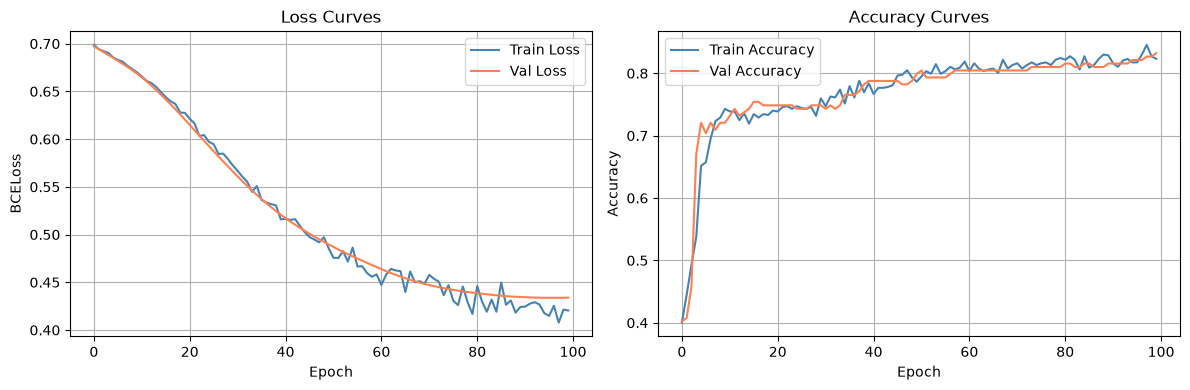

Best val accuracy : 0.8324 at epoch 100
Final val accuracy: 0.8324


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss curves
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCELoss')
axes[0].legend()
axes[0].grid(True)

# accuracy curves
axes[1].plot(train_accs, label='Train Accuracy', color='steelblue')
axes[1].plot(val_accs,   label='Val Accuracy',   color='coral')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('nn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val accuracy : {max(val_accs):.4f} at epoch {val_accs.index(max(val_accs))+1}")
print(f"Final val accuracy: {val_accs[-1]:.4f}")

# Compare with sklearn models:

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# reload unscaled data for sklearn
df2 = pd.read_csv('train.csv')
df2['FamilySize'] = df2['SibSp'] + df2['Parch'] + 1
df2['IsAlone']    = (df2['FamilySize'] == 1).astype(int)
df2['Title']      = df2['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df2['Title']      = df2['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)
df2['Sex']        = df2['Sex'].map({'male': 0, 'female': 1})
df2['Embarked']   = df2['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X_sk = SimpleImputer(strategy='median').fit_transform(df2[features])
y_sk = df2['Survived'].values

skfold = StratifiedKFold(n_splits=5)

# fix — add max_iter=1000 to LogisticRegression
lr_scores = cross_val_score(LogisticRegression(max_iter=1000), X_sk, y_sk,
                             cv=skfold, scoring='accuracy')
rf_scores = cross_val_score(RandomForestClassifier(n_estimators=300,
                             random_state=42), X_sk, y_sk,
                             cv=skfold, scoring='accuracy')

print("=" * 50)
print("   MODEL COMPARISON — TITANIC")
print("=" * 50)
print(f"  Logistic Regression : {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")
print(f"  Random Forest       : {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print(f"  Neural Network      : {max(val_accs):.4f} (single val split)")
print("=" * 50)

   MODEL COMPARISON — TITANIC
  Logistic Regression : 0.8159 ± 0.0097
  Random Forest       : 0.8036 ± 0.0299
  Neural Network      : 0.8324 (single val split)
